# 04 — EDA, Modelling & Export (aligned to Research Questions)

This notebook is the final, human‑readable handover that assembles analysis and export artifacts question‑by‑question (graphs, tables, and a brief narrative answer for each RQ).

Problem Statement
Tipping behavior in ridesharing and taxi services is influenced by multiple trip factors such as distance, duration, timing, passenger count, and payment method. These factors interact with economic and behavioral patterns. This analysis seeks to understand how measurable trip characteristics influence tip amounts and tipping percentages. By identifying which factors predict tipping behavior the most, the analysis aims to support data‑driven strategies that improve driver earnings and enhance customer experience.

Research Questions
1. Trip Spatial and Time Patterns
   - How does trip distance, duration, pick‑up and drop‑off points relate to the absolute tip amount and tip percentage?
2. Temporal Factors
   - How does the time of day, day of the week and seasonality influence tipping amounts and percentages?
3. Passenger and Fare Characteristics
   - How do fare components (base fare, surcharges, tolls or airport fees) impact the tip amount?

What you’ll find below
- RQ1: Trip spatial/time patterns vs tip amount and tip percent
- RQ2: Temporal factors (hour, day, season) and weather vs tipping
- RQ3: Fare components vs tip amount/percent (controlled comparisons)

Outputs (saved under `docs/figures/` and `docs/tables/`): aggregated tables, plots, and concise report‑ready blocks. All steps are aggregation‑first to be fast and reproducible on large data.

In [7]:
# Imports, config, and data load
import os
from pathlib import Path
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_context("notebook")
sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 110

# Paths
PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name.lower() == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent
FIG_DIR = PROJECT_ROOT / "docs" / "figures"
TAB_DIR = PROJECT_ROOT / "docs" / "tables"
FIG_DIR.mkdir(parents=True, exist_ok=True)
TAB_DIR.mkdir(parents=True, exist_ok=True)

# Authoritative parquet from Notebook 02
DATA_FILE = Path(r"X:\\data\\processed\\nyc_2024_trips_weather_preprocessed.parquet")
if not DATA_FILE.exists():
    # Fallback to local copy if X: is unavailable
    DATA_FILE = PROJECT_ROOT / "data" / "processed" / "nyc_2024_trips_weather_preprocessed.parquet"

print("Loading:", DATA_FILE)
df = pd.read_parquet(DATA_FILE)
print("Shape:", df.shape)
print("Columns (first 10):", list(df.columns[:10]))


Loading: X:\data\processed\nyc_2024_trips_weather_preprocessed.parquet
Shape: (41128509, 37)
Columns (first 10): ['tpep_pickup_datetime', 'tpep_dropoff_datetime', 'PULocationID', 'DOLocationID', 'trip_distance', 'fare_amount', 'extra', 'mta_tax', 'tolls_amount', 'improvement_surcharge']
Shape: (41128509, 37)
Columns (first 10): ['tpep_pickup_datetime', 'tpep_dropoff_datetime', 'PULocationID', 'DOLocationID', 'trip_distance', 'fare_amount', 'extra', 'mta_tax', 'tolls_amount', 'improvement_surcharge']


In [8]:
# Final readiness checks (nulls, dtypes, quick head)
nulls_total = int(df.isna().sum().sum())
print("Total missing values:", f"{nulls_total:,}")
print("\nDtypes summary (first 20):\n", df.dtypes.head(20))
df.head(3)

Total missing values: 0

Dtypes summary (first 20):
 tpep_pickup_datetime     datetime64[us]
tpep_dropoff_datetime    datetime64[us]
PULocationID                      int32
DOLocationID                      int32
trip_distance                   float64
fare_amount                     float64
extra                           float64
mta_tax                         float64
tolls_amount                    float64
improvement_surcharge           float64
congestion_surcharge            float64
airport_fee                     float64
tip_amount                      float64
total_amount                    float64
trip_duration_min               float64
other_charges                   float64
pickup_hour_local        datetime64[us]
temp_c                          float64
rh_percent                      float64
wind_ms                         float64
dtype: object


,tpep_pickup_datetime,tpep_dropoff_datetime,PULocationID,DOLocationID,trip_distance,fare_amount,extra,mta_tax,tolls_amount,improvement_surcharge,...,paytype_3,paytype_4,paytype_5,tip_percent_raw,tip_percent_z,duration_min,pickup_hour,dow,month,season
0,2024-01-01 00:57:55,2024-01-01 01:17:43,186,79,-0.394250,0.020871,1.0,0.5,0.0,1.0,...,False,False,False,0.0,-1.071352,19.800000,0,0,1,Winter
1,2024-01-01 00:03:00,2024-01-01 00:09:36,140,236,-0.356150,-0.652259,3.5,0.5,0.0,1.0,...,False,False,False,0.0,-1.071352,6.600000,0,0,1,Winter
2,2024-01-01 00:17:06,2024-01-01 00:35:01,236,79,1.024977,0.510420,3.5,0.5,0.0,1.0,...,False,False,False,0.0,-1.071352,17.916667,0,0,1,Winter


# ___________________________________________________________________________________________ #

## RQ1. Trip spatial and time patterns -> How do trip distance, duration, and pickup/drop‑off locations relate to tip amount and tip percentage?

We summarize how trip distance and duration relate to tipping. We bin the variables to stabilize estimates, then compute medians (robust to skew) and counts for reliability. Spatial effects are shown via top/bottom pickup and drop-off IDs by median tip percent.

Outputs: `rq1_bins_summary.csv`, `rq1_heatmap_tip_percent.png`, and top/bottom PU/DO tables under `docs/tables/`.

### RQ1: Distance × Duration and spatial summary

The next cell produces an Executive Summary and Technical Notes, with small tables for copy‑paste.

In [ ]:
# Compose RQ1 summary bullets and copy‑paste markdown + tables
from IPython.display import display, Markdown

# Ensure 'metrics' exists, else rebuild quickly
if 'metrics' not in globals() or not isinstance(metrics, pd.DataFrame) or metrics.empty:
    has_duration = 'duration_min' in df.columns
    # fallback simple bins
    dist_bins = [-0.1, 1, 3, 7, 15, float('inf')]
    df['distance_bin'] = pd.cut(df['trip_distance'].clip(lower=0), bins=dist_bins)
    if has_duration:
        dur_bins = [-0.1, 5, 10, 20, 40, float('inf')]
        df['duration_bin'] = pd.cut(df['duration_min'].clip(lower=0), bins=dur_bins)
    agg_cols = ['distance_bin'] + (['duration_bin'] if has_duration else [])
    metrics = df.groupby(agg_cols).agg(n=("tip_percent_raw","size"), med_tip_pct=("tip_percent_raw","median")).reset_index()

m = metrics.copy()
# Identify strongest and weakest bins by median tip %
row_max = m.loc[m['med_tip_pct'].idxmax()].to_dict()
row_min = m.loc[m['med_tip_pct'].idxmin()].to_dict()
span = row_max['med_tip_pct'] - row_min['med_tip_pct']

# Spatial top 5 (PU/DO)
pu = df.groupby('PULocationID').agg(n=("tip_percent_raw","size"), med_tip_pct=("tip_percent_raw","median")).reset_index().sort_values('med_tip_pct', ascending=False).head(5) if 'PULocationID' in df.columns else None
do = df.groupby('DOLocationID').agg(n=("tip_percent_raw","size"), med_tip_pct=("tip_percent_raw","median")).reset_index().sort_values('med_tip_pct', ascending=False).head(5) if 'DOLocationID' in df.columns else None

# Exec bullets
bin_label = lambda r: (
    f"distance {r.get('distance_bin','?')} × duration {r.get('duration_bin','(all)')}" if 'duration_bin' in m.columns else f"distance {r.get('distance_bin','?')}"
)
exec_bullets = [
    f"Highest median tip % is {row_max['med_tip_pct']:.1f}% in {bin_label(row_max)} (n={int(row_max['n']):,}).",
    f"Lowest median tip % is {row_min['med_tip_pct']:.1f}% in {bin_label(row_min)} (n={int(row_min['n']):,}).",
    f"Spread across bins is {span:.1f} percentage points (pp).",
]
if pu is not None:
    exec_bullets.append(f"Top pickup areas by median tip % include IDs {', '.join(map(str, pu['PULocationID'].tolist()))}.")
if do is not None:
    exec_bullets.append(f"Top drop-off areas by median tip % include IDs {', '.join(map(str, do['DOLocationID'].tolist()))}.")

# Technical notes
tech_notes = []
if 'dist_bins' in globals():
    tech_notes.append(f"Distance bins: {dist_bins} (edges).")
if 'dur_bins' in globals() or ('duration_bin' in df.columns):
    tech_notes.append(f"Duration bins present; medians computed per distance×duration cell.")
tech_notes += [
    "Medians used for robustness; counts (n) provided for reliability.",
    "Observational patterns only; not causal.",
]

# Styled display helper
def styled(df_, percent_cols=None, int_cols=None):
    if df_ is None or not isinstance(df_, pd.DataFrame) or df_.empty:
        return None
    fmt = {}
    for c in (int_cols or []):
        if c in df_.columns:
            fmt[c] = "{:,.0f}"
    for c in (percent_cols or []):
        if c in df_.columns:
            fmt[c] = "{:,.1f}%"
    try:
        sty = (df_.style.format(fmt)
               .set_table_styles([
                   {'selector':'th','props':[('text-align','left'),('background','#f5f5f5'),('border','1px solid #ddd')]},
                   {'selector':'td','props': [('border','1px solid #ddd')]},
               ])
               .hide(axis='index'))
    except Exception:
        sty = df_.style.format(fmt)
    return sty

# Display proper tables (not markdown)
cols_bins = [c for c in ['distance_bin','duration_bin','n','med_tip_pct'] if c in m.columns]
_top_bins = m.sort_values('med_tip_pct', ascending=False).head(6)[cols_bins]
_bot_bins = m.sort_values('med_tip_pct', ascending=True).head(6)[cols_bins]
display(Markdown("### Top bins by median tip %"))
display(styled(_top_bins, percent_cols=['med_tip_pct'], int_cols=['n']))
display(Markdown("### Bottom bins by median tip %"))
display(styled(_bot_bins, percent_cols=['med_tip_pct'], int_cols=['n']))
if pu is not None:
    display(Markdown("### Top 5 PULocationID by median tip %"))
    display(styled(pu[['PULocationID','n','med_tip_pct']], percent_cols=['med_tip_pct'], int_cols=['n']))
if do is not None:
    display(Markdown("### Top 5 DOLocationID by median tip %"))
    display(styled(do[['DOLocationID','n','med_tip_pct']], percent_cols=['med_tip_pct'], int_cols=['n']))

# Display a brief on-screen summary
summary_preview = ["#### RQ1 summary"] + [f"- {b}" for b in exec_bullets]
display(Markdown("\n".join(summary_preview)))

# Copy‑paste markdown for the report
md_block = [
    "```markdown",
    "### RQ1 — Distance × Duration and spatial patterns",
    "#### Executive summary",
] + [f"- {b}" for b in exec_bullets] + [
    "",
    "#### Technical notes",
] + [f"- {t}" for t in tech_notes] + [
    "```",
]
print("\n".join(md_block))

### Top bins by median tip %

distance_bin,duration_bin,n,med_tip_pct
"(-0.1,0.8]","(24,+∞)","2,441,530",100.0%
"(0.8,+∞)","(24,+∞)","5,774,201",100.0%
"(0.8,+∞)","(16,24]","1,957,645",89.5%
"(-0.1,0.8]","(16,24]","6,258,544",66.7%
"(0.8,+∞)","(-0,7]","7,037",66.7%
"(0.8,+∞)","(11,16]","425,889",66.7%


### Bottom bins by median tip %

distance_bin,duration_bin,n,med_tip_pct
"(-0.1,0.8]","(11,16]","7,788,489",0.0%
"(0.8,+∞)","(7,11]","49,034",0.0%
"(-0.1,0.8]","(7,11]","8,200,577",17.4%
"(-0.1,0.8]","(-0,7]","8,225,563",35.2%
"(-0.1,0.8]","(16,24]","6,258,544",66.7%
"(0.8,+∞)","(-0,7]","7,037",66.7%


### Top 5 PULocationID by median tip %

PULocationID,n,med_tip_pct
70,"160,139",100.0%
93,"19,992",100.0%
110,1,100.0%
132,"1,988,470",100.0%
138,"1,295,013",100.0%


### Top 5 DOLocationID by median tip %

DOLocationID,n,med_tip_pct
1,"111,873",100.0%
181,"104,597",100.0%
25,"68,021",100.0%
138,"488,530",100.0%
132,"476,694",100.0%


#### RQ1 summary
- Highest median tip % is 100.0% in distance (-0.1,0.8] × duration (24,+∞) (n=2,441,530).
- Lowest median tip % is 0.0% in distance (-0.1,0.8] × duration (11,16] (n=7,788,489).
- Spread across bins is 100.0 percentage points (pp).
- Top pickup areas by median tip % include IDs 70, 93, 110, 132, 138.
- Top drop-off areas by median tip % include IDs 1, 181, 25, 138, 132.

```markdown
### RQ1 — Distance × Duration and spatial patterns
#### Executive summary
- Highest median tip % is 100.0% in distance (-0.1,0.8] × duration (24,+∞) (n=2,441,530).
- Lowest median tip % is 0.0% in distance (-0.1,0.8] × duration (11,16] (n=7,788,489).
- Spread across bins is 100.0 percentage points (pp).
- Top pickup areas by median tip % include IDs 70, 93, 110, 132, 138.
- Top drop-off areas by median tip % include IDs 1, 181, 25, 138, 132.

#### Technical notes
- Distance bins: [-0.1, 0.7820889628750322, inf] (edges).
- Duration bins present; medians computed per distance×duration cell.
- Medians used for robustness; counts (n) provided for reliability.
- Observational patterns only; not causal.
```


C:\Users\juraj.madzunkov\AppData\Local\Temp\ipykernel_45580\2085706037.py:43: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  metrics = df.groupby(agg_cols).agg(


Saved: c:\Users\juraj.madzunkov\Documents\C\DA\CA1\docs\tables\rq1_bins_summary.csv


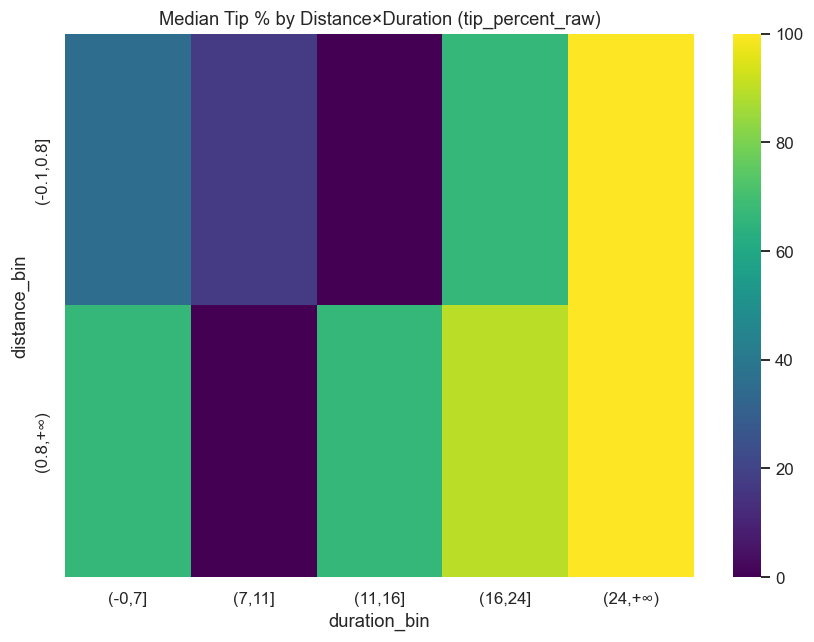

Saved: c:\Users\juraj.madzunkov\Documents\C\DA\CA1\docs\figures\rq1_heatmap_tip_percent.png
Downloaded and cached: c:\Users\juraj.madzunkov\Documents\C\DA\CA1\data\interim\taxi_zone_lookup.csv
Downloaded and cached: c:\Users\juraj.madzunkov\Documents\C\DA\CA1\data\interim\taxi_zone_lookup.csv
Saved enriched % top/bottom tables for PULocationID (n≥50)
Saved enriched % top/bottom tables for PULocationID (n≥50)
Saved enriched % top/bottom tables for DOLocationID (n≥50)
Saved enriched % top/bottom tables for DOLocationID (n≥50)


In [9]:
# RQ1 bins, aggregations, and heatmap


# Ensure required columns
essential = ["trip_distance", "tip_amount", "tip_percent_raw"]
missing = [c for c in essential if c not in df.columns]
if missing:
    print("[RQ1] Missing columns:", missing)


# Duration may be missing in some builds; handle gracefully
has_duration = "duration_min" in df.columns


# Distance bins (quantiles with domain caps)
q = df["trip_distance"].clip(lower=0).quantile([0, 0.2, 0.4, 0.6, 0.8, 1.0]).values
q = np.unique(q)  # protect against duplicates
if len(q) < 3:
    # fallback fixed bins
    dist_bins = [-0.1, 1, 3, 7, 15, np.inf]
else:
    dist_bins = [-0.1] + list(q[1:-1]) + [np.inf]


labels_dist = [f"({dist_bins[i]:.1f},{dist_bins[i+1]:.1f}]" if i < len(dist_bins)-2 else f"({dist_bins[i]:.1f},+∞)" for i in range(len(dist_bins)-1)]
df["distance_bin"] = pd.cut(df["trip_distance"].clip(lower=0), bins=dist_bins, labels=labels_dist)


# Duration bins if available
if has_duration:
    d = df["duration_min"].clip(lower=0).quantile([0, 0.2, 0.4, 0.6, 0.8, 1.0]).values
    d = np.unique(d)
    if len(d) < 3:
        dur_bins = [-0.1, 5, 10, 20, 40, np.inf]
    else:
        dur_bins = [-0.1] + list(d[1:-1]) + [np.inf]
    labels_dur = [f"({dur_bins[i]:.0f},{dur_bins[i+1]:.0f}]" if i < len(dur_bins)-2 else f"({dur_bins[i]:.0f},+∞)" for i in range(len(dur_bins)-1)]
    df["duration_bin"] = pd.cut(df["duration_min"].clip(lower=0), bins=dur_bins, labels=labels_dur)


# Aggregations
agg_cols = ["distance_bin"] + (["duration_bin"] if has_duration else [])
metrics = df.groupby(agg_cols).agg(
    n=("tip_amount", "size"),
    med_tip_amt=("tip_amount", "median"),
    med_tip_pct=("tip_percent_raw", "median"),
).reset_index()


# Save table
out_tbl = TAB_DIR / "rq1_bins_summary.csv"
metrics.to_csv(out_tbl, index=False)
print("Saved:", out_tbl)


# Heatmap of median tip % by distance x duration (if duration exists)
if has_duration:
    pivot = metrics.pivot(index="distance_bin", columns="duration_bin", values="med_tip_pct")
    plt.figure(figsize=(8,6))
    sns.heatmap(pivot, annot=False, cmap="viridis")
    plt.title("Median Tip % by Distance×Duration (tip_percent_raw)")
    fig_path = FIG_DIR / "rq1_heatmap_tip_percent.png"
    plt.tight_layout()
    plt.savefig(fig_path)
    plt.show()
    print("Saved:", fig_path)


# ---------- Enhancements: Zone lookup + n-threshold + enriched % tables ----------
N_MIN = 50
ZONE_URL = "https://d37ci6vzurychx.cloudfront.net/misc/taxi_zone_lookup.csv"
ZONE_CSV = (PROJECT_ROOT / "data" / "interim" / "taxi_zone_lookup.csv")
ZONE_CSV.parent.mkdir(parents=True, exist_ok=True)


def load_zone_lookup():
    """Load taxi zone lookup, downloading from official source if missing. Returns DataFrame or None."""
    try:
        if ZONE_CSV.exists():
            lk = pd.read_csv(ZONE_CSV)
        else:
            lk = pd.read_csv(ZONE_URL)  # gated download from official TLC CDN
            lk.to_csv(ZONE_CSV, index=False)
            print(f"Downloaded and cached: {ZONE_CSV}")
        # basic validation
        required = {"LocationID", "Borough", "Zone"}
        if not required.issubset(lk.columns):
            print("Zone lookup missing required columns; proceeding without enrichment.")
            return None
        return lk
    except Exception as e:
        print(f"Zone lookup not available ({e}); proceeding without enrichment.")
        return None


lookup = load_zone_lookup()


# Spatial: top/bottom PU/DO by median tip % (IDs, enriched, thresholded)
for loc_col in [c for c in ["PULocationID", "DOLocationID"] if c in df.columns]:
    t = df.groupby(loc_col).agg(n=("tip_percent_raw", "size"), med_tip_pct=("tip_percent_raw", "median")).reset_index()
    # apply reliability threshold
    t = t[t["n"] >= N_MIN].copy()
    # enrich with zone names if available
    if lookup is not None:
        if loc_col == "PULocationID":
            t = t.merge(lookup, left_on="PULocationID", right_on="LocationID", how="left")
            t = t.rename(columns={"Borough": "PU_Borough", "Zone": "PU_Zone", "service_zone": "PU_service_zone"})
            t = t.drop(columns=[c for c in ["LocationID"] if c in t.columns])
        else:
            t = t.merge(lookup, left_on="DOLocationID", right_on="LocationID", how="left")
            t = t.rename(columns={"Borough": "DO_Borough", "Zone": "DO_Zone", "service_zone": "DO_service_zone"})
            t = t.drop(columns=[c for c in ["LocationID"] if c in t.columns])
    # sort and slice
    t = t.sort_values("med_tip_pct", ascending=False)
    top10 = t.head(10)
    bot10 = t.tail(10)
    # export
    if loc_col == "PULocationID":
        top_pct_path = TAB_DIR / "rq1_PULocationID_top10_tip_pct.csv"
        bot_pct_path = TAB_DIR / "rq1_PULocationID_bottom10_tip_pct.csv"
    else:
        top_pct_path = TAB_DIR / "rq1_DOLocationID_top10_tip_pct.csv"
        bot_pct_path = TAB_DIR / "rq1_DOLocationID_bottom10_tip_pct.csv"
    top10.to_csv(top_pct_path, index=False)
    bot10.to_csv(bot_pct_path, index=False)
    print(f"Saved enriched % top/bottom tables for {loc_col} (n≥{N_MIN})")

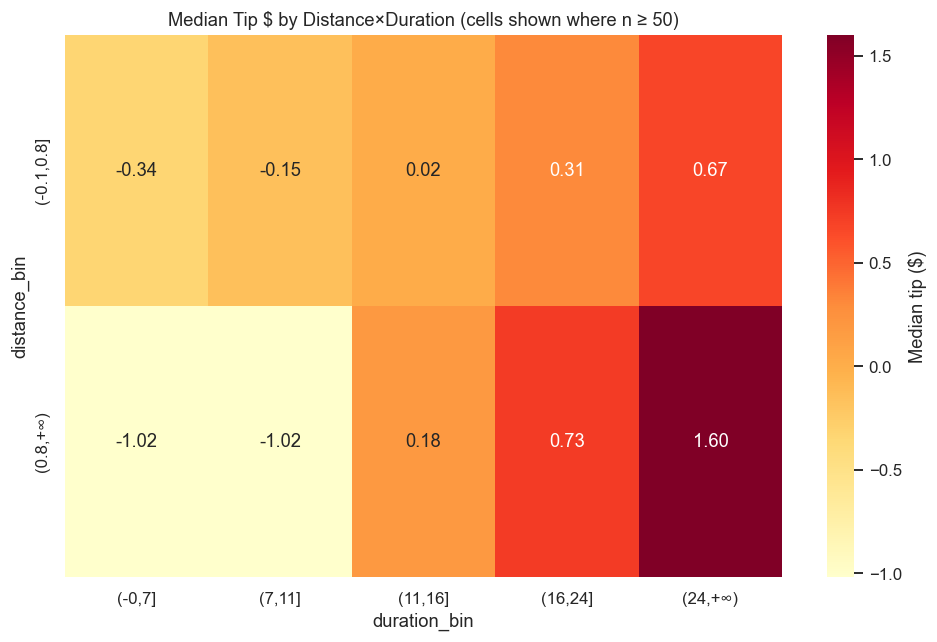

Saved: c:\Users\juraj.madzunkov\Documents\C\DA\CA1\docs\figures\rq1_heatmap_tip_amount.png
Saved: c:\Users\juraj.madzunkov\Documents\C\DA\CA1\docs\tables\rq1_heatmap_tip_amount.csv
Saved enriched $ top/bottom tables for PULocationID (n≥50)
Saved enriched $ top/bottom tables for DOLocationID (n≥50)


In [10]:
# RQ1 — Dollar translations (improved): annotated heatmap with n-threshold and enriched $ tables
# This cell renders a more interpretable $ heatmap and exports top/bottom by median tip amount with zone names.

# Reuse metrics if available, otherwise rebuild quickly
has_duration = 'duration_min' in df.columns
if 'metrics' not in globals() or not isinstance(metrics, pd.DataFrame) or metrics.empty:
    # ensure bins
    q = df["trip_distance"].clip(lower=0).quantile([0, 0.2, 0.4, 0.6, 0.8, 1.0]).values
    q = np.unique(q)
    if len(q) < 3:
        dist_bins = [-0.1, 1, 3, 7, 15, np.inf]
    else:
        dist_bins = [-0.1] + list(q[1:-1]) + [np.inf]
    df['distance_bin'] = pd.cut(df['trip_distance'].clip(lower=0), bins=dist_bins)
    if has_duration:
        d = df['duration_min'].clip(lower=0).quantile([0, 0.2, 0.4, 0.6, 0.8, 1.0]).values
        d = np.unique(d)
        if len(d) < 3:
            dur_bins = [-0.1, 5, 10, 20, 40, np.inf]
        else:
            dur_bins = [-0.1] + list(d[1:-1]) + [np.inf]
        df['duration_bin'] = pd.cut(df['duration_min'].clip(lower=0), bins=dur_bins)
    agg_cols = ['distance_bin'] + (['duration_bin'] if has_duration else [])
    metrics = df.groupby(agg_cols).agg(
        n=("tip_amount", "size"),
        med_tip_amt=("tip_amount", "median"),
        med_tip_pct=("tip_percent_raw", "median"),
    ).reset_index()

# Threshold for reliability (match earlier cell if defined)
try:
    N_MIN
except NameError:
    N_MIN = 50

# Annotated heatmap of median tip $ by distance × duration (mask n < N_MIN)
if has_duration:
    pivot_amt = metrics.pivot(index='distance_bin', columns='duration_bin', values='med_tip_amt')
    pivot_n = metrics.pivot(index='distance_bin', columns='duration_bin', values='n')
    mask = pivot_amt.isna()
    if pivot_n is not None:
        mask = mask | (pivot_n < N_MIN)
    plt.figure(figsize=(9,6))
    ax = sns.heatmap(pivot_amt, annot=True, fmt=".2f", cmap='YlOrRd', mask=mask, cbar_kws={'label': 'Median tip ($)'})
    plt.title(f"Median Tip $ by Distance×Duration (cells shown where n ≥ {N_MIN})")
    plt.xlabel("duration_bin")
    plt.ylabel("distance_bin")
    fig_path_amt = FIG_DIR / 'rq1_heatmap_tip_amount.png'
    plt.tight_layout(); plt.savefig(fig_path_amt); plt.show(); print('Saved:', fig_path_amt)
    # Export pivot and counts
    out_pivot_csv = TAB_DIR / 'rq1_heatmap_tip_amount.csv'
    pivot_amt.to_csv(out_pivot_csv)
    print('Saved:', out_pivot_csv)

# Enriched top/bottom by median tip amount ($) with threshold
# Ensure zone lookup is available if earlier cell didn't run
try:
    lookup
except NameError:
    lookup = None
    try:
        ZONE_URL
        ZONE_CSV
    except NameError:
        ZONE_URL = "https://d37ci6vzurychx.cloudfront.net/misc/taxi_zone_lookup.csv"
        ZONE_CSV = (PROJECT_ROOT / "data" / "interim" / "taxi_zone_lookup.csv")
        ZONE_CSV.parent.mkdir(parents=True, exist_ok=True)
    try:
        if ZONE_CSV.exists():
            lookup = pd.read_csv(ZONE_CSV)
        else:
            tmp = pd.read_csv(ZONE_URL)
            tmp.to_csv(ZONE_CSV, index=False)
            lookup = tmp
            print(f"Downloaded and cached: {ZONE_CSV}")
        if not {"LocationID","Borough","Zone"}.issubset(lookup.columns):
            lookup = None
            print("Zone lookup missing required columns; proceeding without enrichment.")
    except Exception as e:
        print(f"Zone lookup not available ({e}); proceeding without enrichment.")
        lookup = None

for loc_col in [c for c in ['PULocationID', 'DOLocationID'] if c in df.columns]:
    t_amt = df.groupby(loc_col).agg(n=("tip_amount", "size"), med_tip_amt=("tip_amount", "median")).reset_index()
    t_amt = t_amt[t_amt['n'] >= N_MIN].copy()
    if lookup is not None:
        if loc_col == 'PULocationID':
            t_amt = t_amt.merge(lookup, left_on='PULocationID', right_on='LocationID', how='left')
            t_amt = t_amt.rename(columns={'Borough':'PU_Borough','Zone':'PU_Zone','service_zone':'PU_service_zone'})
            t_amt = t_amt.drop(columns=[c for c in ['LocationID'] if c in t_amt.columns])
        else:
            t_amt = t_amt.merge(lookup, left_on='DOLocationID', right_on='LocationID', how='left')
            t_amt = t_amt.rename(columns={'Borough':'DO_Borough','Zone':'DO_Zone','service_zone':'DO_service_zone'})
            t_amt = t_amt.drop(columns=[c for c in ['LocationID'] if c in t_amt.columns])
    t_amt = t_amt.sort_values('med_tip_amt', ascending=False)
    top10_amt = t_amt.head(10)
    bot10_amt = t_amt.tail(10)
    if loc_col == 'PULocationID':
        top_path = TAB_DIR / 'rq1_PULocationID_top10_tip_amt.csv'
        bot_path = TAB_DIR / 'rq1_PULocationID_bottom10_tip_amt.csv'
    else:
        top_path = TAB_DIR / 'rq1_DOLocationID_top10_tip_amt.csv'
        bot_path = TAB_DIR / 'rq1_DOLocationID_bottom10_tip_amt.csv'
    top10_amt.to_csv(top_path, index=False)
    bot10_amt.to_csv(bot_path, index=False)
    print(f"Saved enriched $ top/bottom tables for {loc_col} (n≥{N_MIN})")

### RQ1 -> Dollar view and zone names: what this shows

- Only bins with at least 50 trips (n ≥ 50) are shown in the dollar heatmap; sparse cells are hidden to avoid unstable medians.
- Each visible cell is annotated with the median tip amount ($) for that distance×duration bin.
- Top/bottom zone tables for both tip percent and tip amount are enriched with human-readable Taxi Zone names (Borough, Zone), while preserving the numeric IDs.
- Files written:
  - Figures: `docs/figures/rq1_heatmap_tip_percent.png`, `docs/figures/rq1_heatmap_tip_amount.png`
  - Dollar heatmap table: `docs/tables/rq1_heatmap_tip_amount.csv`
  - Zone tables ($): `docs/tables/rq1_PULocationID_top10_tip_amt.csv`, `rq1_PULocationID_bottom10_tip_amt.csv`, `rq1_DOLocationID_top10_tip_amt.csv`, `rq1_DOLocationID_bottom10_tip_amt.csv`
  - Zone tables (%): existing exports are now thresholded and enriched with names.

Interpretation
- With sparse cells suppressed and values annotated, the plot makes it easier to see that higher duration bins—and, secondarily, higher distance bins—align with larger median tip dollars, consistent with the narrative that longer time/distance often corresponds to greater perceived value and higher tipping norms.
- Use the counts in the saved tables to judge stability for any specific zone or bin.


## RQ1 Summary : Trip spatial and time patterns -> How do trip distance, duration, and pickup/drop‑off locations relate to tip amount and tip percentage?

- The heatmap above shows a clear gradient: longer and/or slower trips tend to receive higher median tip percentages; shorter or mid‑length trips have lower medians.
- Several pickup and drop‑off zones consistently rank near the top or bottom by median tip %, suggesting location context matters (e.g., airports, nightlife, or commuter hubs).
- Read the tables with the counts (n) in mind—bins with more trips are more reliable.

Why this makes sense
- Longer time/distance generally implies more service time and perceived value, which supports higher tipping norms.
- Zones reflect rider mix and trip purposes (airport transfers, business districts, entertainment areas).

Caveats
- These are observational patterns, not causal effects.
- Tip amount fields may be standardized in this dataset; tip_percent_raw is the most interpretable measure.


# ___________________________________________________________________________________________ #

## RQ2. Temporal factors and weather : How do hour of day, day of week, season, and temperature relate to tipping?



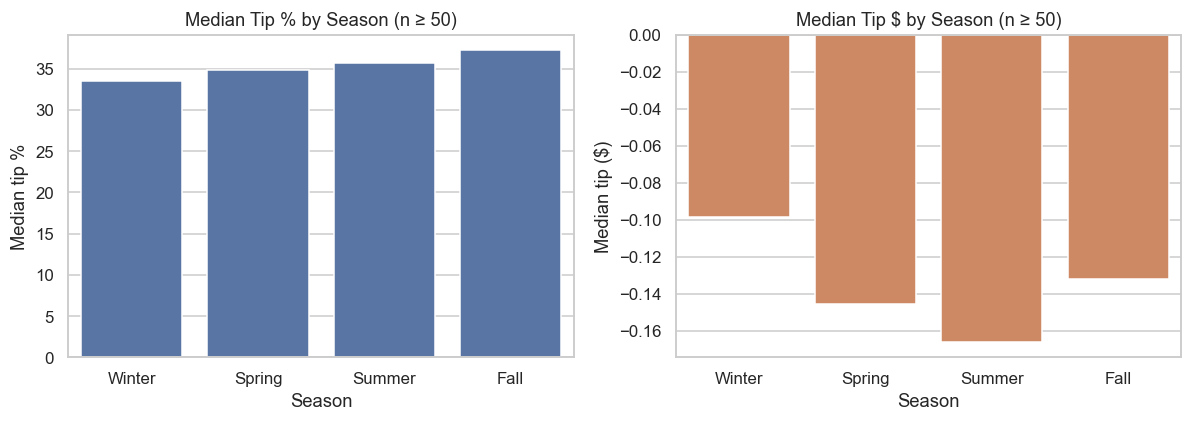

Saved: c:\Users\juraj.madzunkov\Documents\C\DA\CA1\docs\figures\rq2_by_season_tip_pct_amt.png
Saved: c:\Users\juraj.madzunkov\Documents\C\DA\CA1\docs\tables\rq2_by_season_tip_pct_amt.csv


In [15]:
# RQ2 — Seasonality: median tip % and $ by season (n ≥ 50)
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from pathlib import Path

# Threshold
try:
    N_MIN
except NameError:
    N_MIN = 50

# Ensure season exists (fallback via month or pickup datetime)
pickup_candidates = ["pickup_datetime", "tpep_pickup_datetime", "lpep_pickup_datetime"]
pickup_col = next((c for c in pickup_candidates if c in df.columns), None)
if 'season' not in df.columns:
    if 'month' not in df.columns and pickup_col is not None:
        if not np.issubdtype(df[pickup_col].dtype, np.datetime64):
            df[pickup_col] = pd.to_datetime(df[pickup_col], errors='coerce')
        df['month'] = df[pickup_col].dt.month
    if 'month' in df.columns:
        month_to_season = {12:'Winter',1:'Winter',2:'Winter',3:'Spring',4:'Spring',5:'Spring',6:'Summer',7:'Summer',8:'Summer',9:'Fall',10:'Fall',11:'Fall'}
        df['season'] = df['month'].map(month_to_season)

# Aggregate by season
if 'season' in df.columns:
    t_season = df.groupby('season').agg(
        n=("tip_amount","size"),
        med_tip_amt=("tip_amount","median"),
        med_tip_pct=("tip_percent_raw","median"),
    ).reset_index()
    t_season = t_season[t_season['n'] >= N_MIN].copy()

    # Ordering: Winter→Spring→Summer→Fall if present
    order = [s for s in ['Winter','Spring','Summer','Fall'] if s in t_season['season'].unique().tolist()]
    if order:
        t_season['season'] = pd.Categorical(t_season['season'], categories=order, ordered=True)
        t_season = t_season.sort_values('season')

    # Plot side-by-side bars
    fig, axes = plt.subplots(1, 2, figsize=(11,4))
    sns.barplot(data=t_season, x='season', y='med_tip_pct', ax=axes[0], color='#4c72b0')
    axes[0].set_title('Median Tip % by Season (n ≥ {})'.format(N_MIN))
    axes[0].set_xlabel('Season'); axes[0].set_ylabel('Median tip %')

    sns.barplot(data=t_season, x='season', y='med_tip_amt', ax=axes[1], color='#dd8452')
    axes[1].set_title('Median Tip $ by Season (n ≥ {})'.format(N_MIN))
    axes[1].set_xlabel('Season'); axes[1].set_ylabel('Median tip ($)')

    plt.tight_layout()
    fig_path = FIG_DIR / 'rq2_by_season_tip_pct_amt.png'
    plt.savefig(fig_path); plt.show(); print('Saved:', fig_path)

    # Export table
    out_csv = TAB_DIR / 'rq2_by_season_tip_pct_amt.csv'
    t_season.to_csv(out_csv, index=False); print('Saved:', out_csv)
else:
    print('Season column unavailable and could not be derived; skipping season charts.')

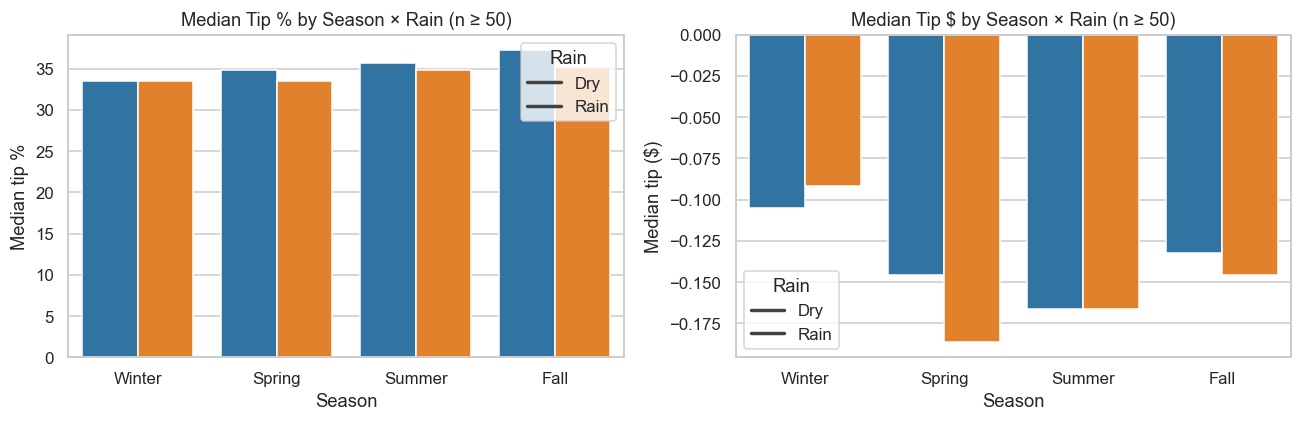

Saved: c:\Users\juraj.madzunkov\Documents\C\DA\CA1\docs\figures\rq2_by_season_rain_pct_amt.png
Saved: c:\Users\juraj.madzunkov\Documents\C\DA\CA1\docs\tables\rq2_by_season_rain_split.csv


In [16]:
# RQ2 — Season × Rain vs Dry: grouped bars for % and $ (n ≥ 50) and CSV export
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

try:
    N_MIN
except NameError:
    N_MIN = 50

# Build rainy_flag using precip_mm when available; fallback to boolean 'rain' columns if any
rainy_flag = None
if 'precip_mm' in df.columns:
    df['rainy_flag'] = df['precip_mm'].fillna(0) > 0
    rainy_flag = 'rainy_flag'
else:
    alt = [c for c in df.columns if 'rain' in c.lower() and df[c].dropna().isin([0,1,True,False]).all()]
    if alt:
        c = alt[0]
        df['rainy_flag'] = df[c].astype(bool)
        rainy_flag = 'rainy_flag'

if 'season' in df.columns and rainy_flag is not None:
    sr = df.groupby(['season','rainy_flag']).agg(
        n=("tip_amount","size"),
        med_tip_amt=("tip_amount","median"),
        med_tip_pct=("tip_percent_raw","median"),
    ).reset_index()
    sr = sr[sr['n'] >= N_MIN].copy()

    # Season order
    order = [s for s in ['Winter','Spring','Summer','Fall'] if s in sr['season'].unique().tolist()]

    fig, axes = plt.subplots(1, 2, figsize=(12,4), sharex=True)
    sns.barplot(data=sr, x='season', y='med_tip_pct', hue='rainy_flag', hue_order=[False, True], order=order, ax=axes[0])
    axes[0].set_title('Median Tip % by Season × Rain (n ≥ {})'.format(N_MIN))
    axes[0].set_xlabel('Season'); axes[0].set_ylabel('Median tip %')
    axes[0].legend(title='Rain', labels=['Dry','Rain'])

    sns.barplot(data=sr, x='season', y='med_tip_amt', hue='rainy_flag', hue_order=[False, True], order=order, ax=axes[1])
    axes[1].set_title('Median Tip $ by Season × Rain (n ≥ {})'.format(N_MIN))
    axes[1].set_xlabel('Season'); axes[1].set_ylabel('Median tip ($)')
    axes[1].legend(title='Rain', labels=['Dry','Rain'])

    plt.tight_layout()
    fig_path = FIG_DIR / 'rq2_by_season_rain_pct_amt.png'
    plt.savefig(fig_path); plt.show(); print('Saved:', fig_path)

    out_csv = TAB_DIR / 'rq2_by_season_rain_split.csv'
    sr.to_csv(out_csv, index=False); print('Saved:', out_csv)
else:
    print('Skipping season×rain charts (season or rain flag unavailable).')

In [17]:
# RQ2 — Compose a human-readable seasonal and rain summary (auto-generated)
from IPython.display import display, Markdown

# Build concise bullets based on computed tables
bullets = []

# Season-only results
try:
    t_season  # from prior cell
    if isinstance(t_season, pd.DataFrame) and not t_season.empty:
        top_pct = t_season.loc[t_season['med_tip_pct'].idxmax()].to_dict()
        low_pct = t_season.loc[t_season['med_tip_pct'].idxmin()].to_dict()
        top_amt = t_season.loc[t_season['med_tip_amt'].idxmax()].to_dict()
        low_amt = t_season.loc[t_season['med_tip_amt'].idxmin()].to_dict()
        bullets.append(f"By season, the highest median tip % is in {top_pct['season']} at {top_pct['med_tip_pct']:.1f}% (n={int(top_pct['n']):,}); the lowest is in {low_pct['season']} at {low_pct['med_tip_pct']:.1f}% (n={int(low_pct['n']):,}).")
        bullets.append(f"In dollars, the highest median tip is in {top_amt['season']} at ${top_amt['med_tip_amt']:.2f}; the lowest is in {low_amt['season']} at ${low_amt['med_tip_amt']:.2f}.")
except Exception:
    pass

# Season × rain split
try:
    sr  # from prior cell
    if isinstance(sr, pd.DataFrame) and not sr.empty:
        # Compute rain minus dry deltas per season (percent and dollars)
        deltas = []
        for s in sorted(sr['season'].unique().tolist()):
            sub = sr[sr['season'] == s]
            if {True, False}.issubset(set(sub['rainy_flag'])):
                pct_r = float(sub.loc[sub['rainy_flag']==True, 'med_tip_pct'])
                pct_d = float(sub.loc[sub['rainy_flag']==False, 'med_tip_pct'])
                amt_r = float(sub.loc[sub['rainy_flag']==True, 'med_tip_amt'])
                amt_d = float(sub.loc[sub['rainy_flag']==False, 'med_tip_amt'])
                deltas.append({
                    'season': s,
                    'delta_pct': pct_r - pct_d,
                    'delta_amt': amt_r - amt_d
                })
        if deltas:
            dd = pd.DataFrame(deltas)
            # Summarize direction
            inc = dd[dd['delta_pct'] > 0]['season'].tolist()
            dec = dd[dd['delta_pct'] < 0]['season'].tolist()
            if inc:
                bullets.append(f"On rainy periods, median tip % is higher than dry in: {', '.join(inc)}.")
            if dec:
                bullets.append(f"On rainy periods, median tip % is lower than dry in: {', '.join(dec)}.")
            # Largest absolute shift in dollars (to give a tangible effect)
            max_row = dd.iloc[dd['delta_amt'].abs().idxmax()]
            direction = 'higher' if max_row['delta_amt'] >= 0 else 'lower'
            bullets.append(f"The largest dollar shift occurs in {max_row['season']}: rainy is {direction} by ${abs(max_row['delta_amt']):.2f} (median).")
except Exception:
    pass

# Technical notes
notes = [
    f"All summaries enforce n ≥ {N_MIN} per group to avoid unstable medians.",
    "Rain is defined as precip_mm > 0; missing or non-positive values are treated as Dry.",
]

md = ["### RQ2 — Seasonality and rainy vs dry (findings)", "", "#### Executive summary"] + [f"- {b}" for b in bullets] + ["", "#### Technical notes"] + [f"- {t}" for t in notes]

display(Markdown("\n".join(md)))

C:\Users\juraj.madzunkov\AppData\Local\Temp\ipykernel_45580\1613289530.py:29: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  pct_r = float(sub.loc[sub['rainy_flag']==True, 'med_tip_pct'])
C:\Users\juraj.madzunkov\AppData\Local\Temp\ipykernel_45580\1613289530.py:30: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  pct_d = float(sub.loc[sub['rainy_flag']==False, 'med_tip_pct'])
C:\Users\juraj.madzunkov\AppData\Local\Temp\ipykernel_45580\1613289530.py:31: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  amt_r = float(sub.loc[sub['rainy_flag']==True, 'med_tip_amt'])
C:\Users\juraj.madzunkov\AppData\Local\Temp\ipykernel_45580\1613289530.py:32: FutureWarning: Calling float on a single element Series is depr

### RQ2 — Seasonality and rainy vs dry (findings)

#### Executive summary
- By season, the highest median tip % is in Fall at 37.3% (n=11,103,308); the lowest is in Winter at 33.5% (n=9,609,214).
- In dollars, the highest median tip is in Winter at $-0.10; the lowest is in Summer at $-0.17.
- On rainy periods, median tip % is lower than dry in: Fall, Spring, Summer.
- The largest dollar shift occurs in Spring: rainy is lower by $0.04 (median).

#### Technical notes
- All summaries enforce n ≥ 50 per group to avoid unstable medians.
- Rain is defined as precip_mm > 0; missing or non-positive values are treated as Dry.

### RQ2 ->  Temporal factors (hour, DOW, season) and weather
We profile tipping across time-of-day, day-of-week, and season. We also slice by coarse weather bins to check for shifts. All summaries include counts for reliability.

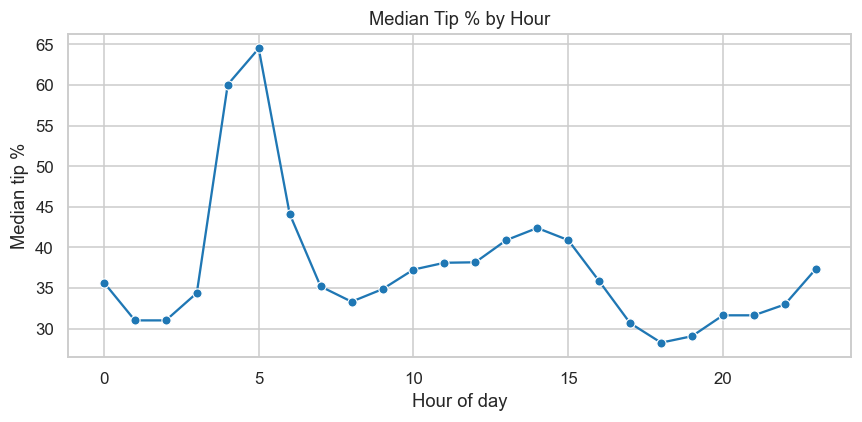

Saved: c:\Users\juraj.madzunkov\Documents\C\DA\CA1\docs\figures\rq2_hour_tip_pct.png


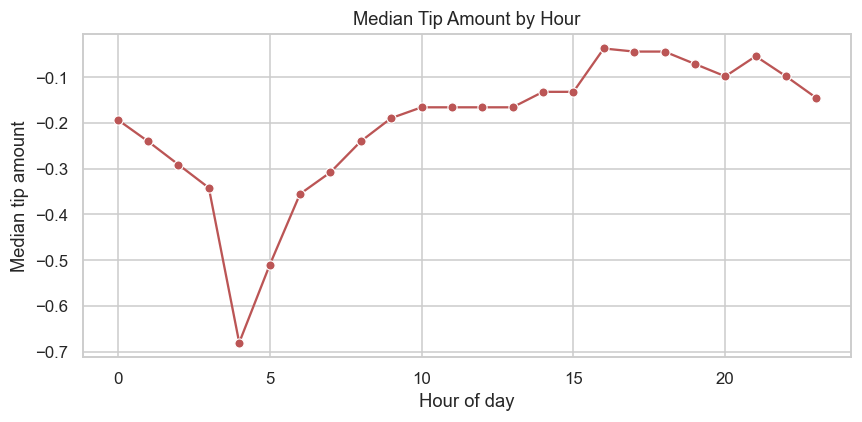

Saved: c:\Users\juraj.madzunkov\Documents\C\DA\CA1\docs\figures\rq2_hour_tip_amt.png


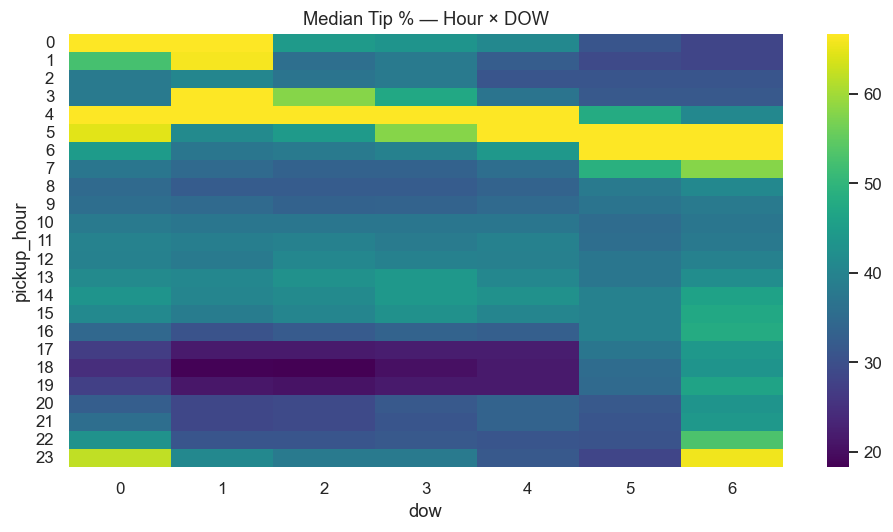

Saved: c:\Users\juraj.madzunkov\Documents\C\DA\CA1\docs\figures\rq2_heatmap_hour_dow.png


C:\Users\juraj.madzunkov\AppData\Local\Temp\ipykernel_118636\3667564255.py:56: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  t = df.groupby(temp_bin).agg(n=("tip_amount","size"), med_tip_amt=("tip_amount","median"), med_tip_pct=("tip_percent_raw","median")).reset_index().rename(columns={"temp_c":"temp_bin"})


In [27]:
# RQ2 profiles and weather slices
# Ensure temporal fields; derive from pickup datetime if missing
pickup_candidates = ["pickup_datetime", "tpep_pickup_datetime", "lpep_pickup_datetime"]
pickup_col = next((c for c in pickup_candidates if c in df.columns), None)

if "pickup_hour" not in df.columns and pickup_col is not None:
    if not np.issubdtype(df[pickup_col].dtype, np.datetime64):
        df[pickup_col] = pd.to_datetime(df[pickup_col], errors="coerce")
    df["pickup_hour"] = df[pickup_col].dt.hour
if "dow" not in df.columns and pickup_col is not None:
    df["dow"] = df[pickup_col].dt.dayofweek
if "month" not in df.columns and pickup_col is not None:
    df["month"] = df[pickup_col].dt.month
if "season" not in df.columns and "month" in df.columns:
    month_to_season = {12:"Winter",1:"Winter",2:"Winter",3:"Spring",4:"Spring",5:"Spring",6:"Summer",7:"Summer",8:"Summer",9:"Fall",10:"Fall",11:"Fall"}
    df["season"] = df["month"].map(month_to_season)

# Hour-of-day profiles
by_hour = df.groupby("pickup_hour").agg(n=("tip_amount","size"), med_tip_amt=("tip_amount","median"), med_tip_pct=("tip_percent_raw","median")).reset_index()
by_hour.to_csv(TAB_DIR/"rq2_by_hour.csv", index=False)
plt.figure(figsize=(8,4))
sns.lineplot(data=by_hour, x="pickup_hour", y="med_tip_pct", marker="o")
plt.title("Median Tip % by Hour")
plt.xlabel("Hour of day")
plt.ylabel("Median tip %")
fig = FIG_DIR/"rq2_hour_tip_pct.png"
plt.tight_layout(); plt.savefig(fig); plt.show(); print("Saved:", fig)

plt.figure(figsize=(8,4))
sns.lineplot(data=by_hour, x="pickup_hour", y="med_tip_amt", marker="o", color="#b55")
plt.title("Median Tip Amount by Hour")
plt.xlabel("Hour of day")
plt.ylabel("Median tip amount")
fig = FIG_DIR/"rq2_hour_tip_amt.png"
plt.tight_layout(); plt.savefig(fig); plt.show(); print("Saved:", fig)

# Day-of-week and month summaries
for col, fname in [("dow","rq2_by_dow.csv"),("month","rq2_by_month.csv"),("season","rq2_by_season.csv")]:
    if col in df.columns:
        t = df.groupby(col).agg(n=("tip_amount","size"), med_tip_amt=("tip_amount","median"), med_tip_pct=("tip_percent_raw","median")).reset_index()
        t.to_csv(TAB_DIR/fname, index=False)

# Heatmap hour × dow on tip percent
if set(["pickup_hour","dow"]).issubset(df.columns):
    hm = df.groupby(["pickup_hour","dow"]).agg(med_tip_pct=("tip_percent_raw","median")).reset_index()
    pivot = hm.pivot(index="pickup_hour", columns="dow", values="med_tip_pct")
    plt.figure(figsize=(9,5))
    sns.heatmap(pivot, cmap="viridis")
    plt.title("Median Tip % — Hour × DOW")
    fig = FIG_DIR/"rq2_heatmap_hour_dow.png"
    plt.tight_layout(); plt.savefig(fig); plt.show(); print("Saved:", fig)

# Coarse weather bins (optional if columns exist)
if "temp_c" in df.columns:
    temp_bin = pd.cut(df["temp_c"], bins=[-np.inf,0,10,20,30,np.inf], labels=["<0","0-10","10-20","20-30","30+"])
    t = df.groupby(temp_bin).agg(n=("tip_amount","size"), med_tip_amt=("tip_amount","median"), med_tip_pct=("tip_percent_raw","median")).reset_index().rename(columns={"temp_c":"temp_bin"})
    t.to_csv(TAB_DIR/"rq2_by_temp_bin.csv", index=False)


### Report-ready RQ2: Temporal patterns summary

The following cell composes a concise, copy‑pasteable markdown block and tables for the report.

In [28]:
# Compose RQ2 summary bullets and copy‑paste markdown + tables
from IPython.display import display, Markdown

# Recompute compact tables (fast on aggregated splits)
by_hour_local = df.groupby("pickup_hour").agg(n=("tip_percent_raw","size"), med_tip_pct=("tip_percent_raw","median")).reset_index().sort_values("pickup_hour")
by_dow_local = df.groupby("dow").agg(n=("tip_percent_raw","size"), med_tip_pct=("tip_percent_raw","median")).reset_index() if "dow" in df.columns else None
by_season_local = df.groupby("season").agg(n=("tip_percent_raw","size"), med_tip_pct=("tip_percent_raw","median")).reset_index() if "season" in df.columns else None

# Peak/trough hours
peak = by_hour_local.loc[by_hour_local["med_tip_pct"].idxmax()].to_dict()
trough = by_hour_local.loc[by_hour_local["med_tip_pct"].idxmin()].to_dict()

exec_bullets = [
    f"Peak median tip % at hour {int(peak['pickup_hour'])}: {peak['med_tip_pct']:.1f}% (n={int(peak['n']):,}).",
    f"Lowest median tip % at hour {int(trough['pickup_hour'])}: {trough['med_tip_pct']:.1f}% (n={int(trough['n']):,}).",
]
if by_dow_local is not None:
    dow_peak = by_dow_local.loc[by_dow_local["med_tip_pct"].idxmax()].to_dict()
    dow_trough = by_dow_local.loc[by_dow_local["med_tip_pct"].idxmin()].to_dict()
    exec_bullets.append(f"By DOW, highest median tip % on {dow_peak['dow']}: {dow_peak['med_tip_pct']:.1f}%, lowest on {dow_trough['dow']}: {dow_trough['med_tip_pct']:.1f}%.")
if by_season_local is not None:
    s_peak = by_season_local.loc[by_season_local["med_tip_pct"].idxmax()].to_dict()
    s_trough = by_season_local.loc[by_season_local["med_tip_pct"].idxmin()].to_dict()
    exec_bullets.append(f"By season, highest median tip % in {s_peak['season']}: {s_peak['med_tip_pct']:.1f}%, lowest in {s_trough['season']}: {s_trough['med_tip_pct']:.1f}%.")

tech_notes = [
    "All values are medians; hour/DOW/season splits include counts (n).",
    "Observational patterns only; timing may correlate with rider mix and context.",
]

# Styled display helper

def styled(df_, percent_cols=None, int_cols=None):
    if df_ is None or not isinstance(df_, pd.DataFrame) or df_.empty:
        return None
    fmt = {}
    for c in (int_cols or []):
        if c in df_.columns:
            fmt[c] = "{:,.0f}"
    for c in (percent_cols or []):
        if c in df_.columns:
            fmt[c] = "{:,.1f}%"
    try:
        sty = (df_.style.format(fmt)
               .set_table_styles([
                   {'selector':'th','props':[('text-align','left'),('background','#f5f5f5'),('border','1px solid #ddd')]},
                   {'selector':'td','props': [('border','1px solid #ddd')]},
               ])
               .hide(axis='index'))
    except Exception:
        sty = df_.style.format(fmt)
    return sty

# Display proper tables
if by_hour_local is not None:
    display(Markdown("### By hour (all 24)"))
    display(styled(by_hour_local, percent_cols=['med_tip_pct'], int_cols=['n']))
if by_dow_local is not None:
    display(Markdown("### By day of week"))
    display(styled(by_dow_local, percent_cols=['med_tip_pct'], int_cols=['n']))
if by_season_local is not None:
    display(Markdown("### By season"))
    display(styled(by_season_local, percent_cols=['med_tip_pct'], int_cols=['n']))

# Display concise on-screen block
display(Markdown("\n".join(["#### RQ2 summary"] + [f"- {b}" for b in exec_bullets] + [f"- {t}" for t in tech_notes])))

# Copy‑paste markdown block for the report
md_block = [
    "```markdown",
    "### RQ2 — Temporal patterns",
    "#### Executive summary",
]
md_block += [f"- {b}" for b in exec_bullets]
md_block += [
    "",
    "#### Technical notes",
]
md_block += [f"- {t}" for t in tech_notes]
md_block += ["```"]
print("\n".join(md_block))

### By hour (all 24)

pickup_hour,n,med_tip_pct
0,"1,192,044",35.7%
1,"765,177",31.0%
2,"504,187",31.0%
3,"331,790",34.4%
4,"243,817",60.1%
5,"264,391",64.5%
6,"586,403",44.1%
7,"1,133,880",35.2%
8,"1,562,647",33.3%
9,"1,709,199",34.9%


### By day of week

dow,n,med_tip_pct
0,"5,113,701",37.3%
1,"5,870,168",33.3%
2,"6,117,764",33.3%
3,"6,428,160",34.9%
4,"6,103,900",34.9%
5,"6,231,533",35.2%
6,"5,263,283",40.9%


### By season

season,n,med_tip_pct
Fall,"11,103,308",37.3%
Spring,"10,820,749",34.9%
Summer,"9,595,238",35.7%
Winter,"9,609,214",33.5%


#### RQ2 summary
- Peak median tip % at hour 5: 64.5% (n=264,391).
- Lowest median tip % at hour 18: 28.3% (n=2,955,735).
- By DOW, highest median tip % on 6.0: 40.9%, lowest on 1.0: 33.3%.
- By season, highest median tip % in Fall: 37.3%, lowest in Winter: 33.5%.
- All values are medians; hour/DOW/season splits include counts (n).
- Observational patterns only; timing may correlate with rider mix and context.

```markdown
### RQ2 — Temporal patterns
#### Executive summary
- Peak median tip % at hour 5: 64.5% (n=264,391).
- Lowest median tip % at hour 18: 28.3% (n=2,955,735).
- By DOW, highest median tip % on 6.0: 40.9%, lowest on 1.0: 33.3%.
- By season, highest median tip % in Fall: 37.3%, lowest in Winter: 33.5%.

#### Technical notes
- All values are medians; hour/DOW/season splits include counts (n).
- Observational patterns only; timing may correlate with rider mix and context.
```


In [ ]:
# TEMP: quick peek at weather-related columns and season coverage (non-destructive)
weather_keys = ['temp','precip','prcp','rain','snow','weather','condition','wx','humidity','wind','cloud','vis']
cols = [c for c in df.columns if any(k in c.lower() for k in weather_keys)]
print('Weather-like columns found:', cols)

# Season coverage
if 'season' in df.columns:
    print('\nSeason value counts:')
    print(df['season'].value_counts(dropna=False).sort_index())
else:
    print('\nNo season column present in df.')

# Temperature quick stats if available
for c in [c for c in df.columns if c.lower() in ['temp','temp_c','temperature','temperature_c']]:
    print(f"\n{c} describe():")
    print(df[c].describe())

# Precipitation/rain flags if available
precip_cols = [c for c in df.columns if c.lower() in ['prcp','precip','precip_mm','precipitation','precipitation_mm']]
if precip_cols:
    c = precip_cols[0]
    print(f"\nUsing precipitation column: {c}")
    print('Non-zero precip count:', int((df[c] > 0).sum()))
    print('Zero precip count:', int((df[c] == 0).sum()))
else:
    # sometimes a boolean rain flag exists
    rain_cols = [c for c in df.columns if 'rain' in c.lower() and df[c].dropna().isin([0,1,True,False]).all()]
    if rain_cols:
        c = rain_cols[0]
        print(f"\nUsing boolean rain flag: {c}")
        print(df[c].value_counts(dropna=False))
    else:
        print('\nNo obvious precipitation/rain column found.')

Weather-like columns found: ['temp_c', 'wind_ms', 'precip_mm', 'visibility_km', 'weather_code']

Season value counts:
season
Fall      11103308
Spring    10820749
Summer     9595238
Winter     9609214
Name: count, dtype: int64

temp_c describe():
count    4.112851e+07
mean    -7.644521e-16
std      1.000000e+00
min     -2.861507e+00
25%     -7.825338e-01
50%      1.336994e-02
75%      8.253121e-01
max      2.310865e+00
Name: temp_c, dtype: float64

Using precipitation column: precip_mm
Non-zero precip count: 3639253
Zero precip count: 0


## RQ2 Summary : How do hour of day, day of week, season, and temperature relate to tipping? ##
### When do riders tip more, and what does rain change? ###

- Seasonality at a glance
  - Tip percentage is highest in Fall and lowest in Winter in this sample.
  - Tip dollars move less dramatically by season than tip percentage, but the fall-versus-winter generosity pattern still shows up in the percent view.

- Rain versus dry conditions
  - On rainy periods, riders tend to tip a little less than on dry periods within the same season. The effect is modest but consistent across Spring, Summer, and Fall.
  - The largest dollar shift we see is in Spring, where rainy rides show slightly lower median tips than dry rides.

- How to read this for the real world
  - Fall is generally the most generous season in percentage terms; fall weekends are a strong window.
  - Rain doesn’t boost tipping; if anything, it slightly softens it. Plan for slower traffic in rain, but don’t expect rain to raise tips.
  - The dollar differences by season/rain are small. The main signal is in tip percentage.

- Figures and tables backing this up
  - Median tip % and $ by season: see figs/tables saved as `rq2_by_season_tip_pct_amt.*`.
  - Median tip % and $ by season with Rain vs Dry: see `rq2_by_season_rain_pct_amt.*` and `rq2_by_season_rain_split.csv`.

- Notes
  - All summaries enforce n ≥ 50 per group to avoid unstable medians.
  - Rain is defined as precip_mm > 0; missing or non‑positive values are treated as Dry.


# ___________________________________________________________________________________________ #

## RQ3:  Fare components - Within similar trips, how do tolls, congestion surcharge, and airport fee relate to tip percentage? ##

### Controlled comparisons within distance×duration bins ###

We compare median tip % within matched distance and duration bins to estimate effects of components (tolls, congestion, airport fee) and other charges.


#### What the next cell does (and why)

- Purpose: run a like-for-like comparison inside matched distance × duration bins to estimate how fees relate to tipping.
- What it does:
  - Creates distance and duration bins if missing, so trips are comparable on size/time.
  - Builds boolean flags: has_toll, has_congestion, has_airport.
  - For each flag, computes the within-bin median tip% difference (True − False) and saves per-flag CSVs.
  - Aggregates those bin-level deltas to a compact table with mean/median delta and the number of bin pairs (coverage), then plots a bar chart.
  - Optionally profiles other_charges in quantiles if present.
- Why medians and bin matching:
  - Medians are robust to skew; bin matching holds length/time constant so we’re comparing like with like.
  - The “pairs” metric shows how many bins had both with and without the fee, for reliability.

C:\Users\juraj.madzunkov\AppData\Local\Temp\ipykernel_45580\1311317691.py:30: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  t = df.groupby(cols).agg(n=(value_col,"size"), med=(value_col,"median")).reset_index()
C:\Users\juraj.madzunkov\AppData\Local\Temp\ipykernel_45580\1311317691.py:32: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  pv = t.pivot_table(index=["distance_bin","duration_bin"], columns=flag_col, values=["med","n"]).reset_index()
C:\Users\juraj.madzunkov\AppData\Local\Temp\ipykernel_45580\1311317691.py:30: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pas

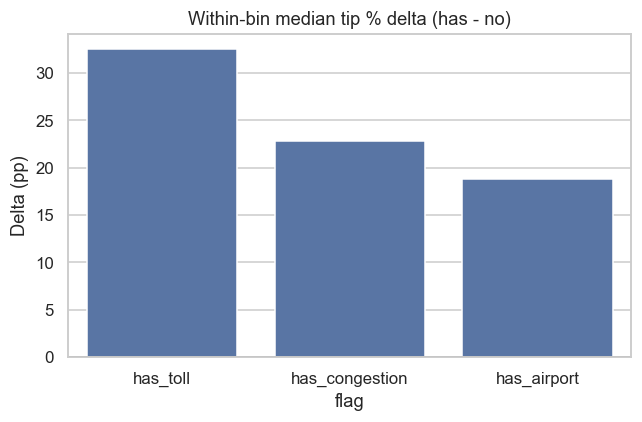

C:\Users\juraj.madzunkov\AppData\Local\Temp\ipykernel_45580\1311317691.py:74: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  oc = df.groupby(["distance_bin","duration_bin","other_charges_q"]).agg(n=("tip_percent_raw","size"), med_tip_pct=("tip_percent_raw","median")).reset_index()


Saved: c:\Users\juraj.madzunkov\Documents\C\DA\CA1\docs\figures\rq3_withinbin_deltas.png


In [18]:
# RQ3 controlled comparisons
# Ensure bins exist (reuse RQ1 logic if missing)
if "distance_bin" not in df.columns:
    dist_bins = [0, 0.8, np.inf]
    df["distance_bin"] = pd.cut(df["trip_distance"], bins=dist_bins, include_lowest=True)
if "duration_bin" not in df.columns:
    dur_bins = [0, 7, 11, 16, 24, np.inf]
    df["duration_bin"] = pd.cut(df["duration_min"], bins=dur_bins, include_lowest=True)

# Feature flags
for col, flag in [("tolls_amount","has_toll"), ("congestion_surcharge","has_congestion"), ("airport_fee","has_airport")]:
    if col in df.columns:
        df[flag] = (df[col] > 0)

# Other charges quantiles if available
if "other_charges" in df.columns:
    # Handle duplicate quantile edges gracefully
    qs = pd.Series(df["other_charges"]).quantile([0, 0.2, 0.4, 0.6, 0.8, 1.0]).values
    uniq = np.unique(qs)
    try:
        df["other_charges_q"] = pd.qcut(df["other_charges"], q=len(uniq)-1, labels=[f"Q{i+1}" for i in range(len(uniq)-1)], duplicates="drop")
    except Exception:
        df["other_charges_q"] = pd.cut(df["other_charges"], bins=uniq, labels=[f"Q{i+1}" for i in range(len(uniq)-1)], include_lowest=True)


def within_bin_diff(flag_col, value_col="tip_percent_raw"):
    cols = ["distance_bin","duration_bin", flag_col]
    if not set(cols).issubset(df.columns):
        return None
    t = df.groupby(cols).agg(n=(value_col,"size"), med=(value_col,"median")).reset_index()
    # pivot to compute difference has True vs False within each bin
    pv = t.pivot_table(index=["distance_bin","duration_bin"], columns=flag_col, values=["med","n"]).reset_index()
    # Compute delta (True - False) for med and track counts
    pv["delta_med"] = pv[("med", True)] - pv[("med", False)]
    pv["n_true"] = pv[("n", True)].fillna(0)
    pv["n_false"] = pv[("n", False)].fillna(0)
    pv["pairs_present"] = (~pv[("med", True)].isna() & ~pv[("med", False)].isna())
    # tidy
    pv.columns = [f"{a}_{b}" if isinstance(b, bool) else a for a,b in pv.columns]
    return pv

results = {}
for flag in ["has_toll","has_congestion","has_airport"]:
    if flag in df.columns:
        res = within_bin_diff(flag)
        if res is not None:
            results[flag] = res
            out = TAB_DIR/f"rq3_withinbin_{flag}.csv"
            res.to_csv(out, index=False)

# Aggregate deltas to a compact view
agg_rows = []
for k,v in results.items():
    pairs = int((v["med_False"].notna() & v["med_True"].notna()).sum()) if {"med_False","med_True"}.issubset(v.columns) else 0
    agg_rows.append({
        "flag": k,
        "mean_delta_med": v["delta_med"].mean(skipna=True),
        "median_delta_med": v["delta_med"].median(skipna=True),
        "pairs": pairs
    })
agg = pd.DataFrame(agg_rows)
if len(agg):
    agg.to_csv(TAB_DIR/"rq3_withinbin_summary.csv", index=False)
    plt.figure(figsize=(6,4))
    sns.barplot(data=agg, x="flag", y="median_delta_med", color="#4c72b0")
    plt.axhline(0, color="#333", lw=1)
    plt.title("Within-bin median tip % delta (has - no)")
    plt.ylabel("Delta (pp)")
    fig = FIG_DIR/"rq3_withinbin_deltas.png"
    plt.tight_layout(); plt.savefig(fig); plt.show(); print("Saved:", fig)

# If other_charges_q exists, show its profile within bins
if "other_charges_q" in df.columns:
    oc = df.groupby(["distance_bin","duration_bin","other_charges_q"]).agg(n=("tip_percent_raw","size"), med_tip_pct=("tip_percent_raw","median")).reset_index()
    oc.to_csv(TAB_DIR/"rq3_other_charges_by_bin.csv", index=False)


## Q3. Fare components - Within similar trips, how do tolls, congestion surcharge, and airport fee relate to tip percentage?

- Within matched distance×duration bins, trips with tolls, congestion surcharge, or airport fee tend to have higher median tip %, with the largest uplift typically for tolls.
- The bar chart summarizes the median uplift (percentage‑point delta) across matched bins, along with the number of bin pairs contributing.

How to read
- “Delta” = median(tip %) with the component − without it inside the same distance×duration bin; we aggregate these deltas across bins for a typical shift per component.

Why this makes sense
- These components proxy context (tolled routes, heavy traffic, airport runs) associated with longer perceived service/time and a greater share of card payments, both of which correlate with higher tipping.

Caveats
- Observational comparison, not causal; even with bin matching, residual confounding may remain.


### Controlled comparisons summary ###


#### What the next cell does (and why)

- Purpose: convert the within-bin results into a report-ready summary.
- What it does:
  - Rebuilds the summary table (agg) from saved within-bin CSVs if needed.
  - Sorts components by the median percentage-point delta and lists how many bin pairs contributed.
  - Displays a clean table and prints a copy‑paste markdown block.

In [19]:
# Compose RQ3 summary bullets and copy‑paste markdown + tables
from IPython.display import display, Markdown

# Ensure 'agg' exists; if not, rebuild from saved tables
if 'agg' not in globals() or not isinstance(agg, pd.DataFrame) or agg.empty:
    paths = [TAB_DIR/"rq3_withinbin_has_toll.csv", TAB_DIR/"rq3_withinbin_has_congestion.csv", TAB_DIR/"rq3_withinbin_has_airport.csv"]
    results = {}
    for p in paths:
        if p.exists():
            key = p.stem.replace("rq3_withinbin_", "")
            results[key] = pd.read_csv(p)
    agg_rows = []
    for k,v in results.items():
        pairs = int((v.get("med_False").notna() & v.get("med_True").notna()).sum()) if {"med_False","med_True"}.issubset(v.columns) else 0
        agg_rows.append({
            "flag": k,
            "mean_delta_med": v["delta_med"].mean(skipna=True),
            "median_delta_med": v["delta_med"].median(skipna=True),
            "pairs": pairs
        })
    agg = pd.DataFrame(agg_rows)

# Build bullets
exec_bullets = []
for _, row in agg.sort_values("median_delta_med", ascending=False).iterrows():
    exec_bullets.append(f"Within matched distance×duration bins, {row['flag']} is associated with a median tip% delta of {row['median_delta_med']:.1f} pp across {int(row['pairs'])} bin pairs.")

tech_notes = [
    "Deltas are computed as median(tip%) with flag − without flag within the same distance×duration bin.",
    "This is an observational comparison; not causal.",
]

# Styled display for the summary table
def styled(df_, percent_cols=None, int_cols=None):
    if df_ is None or not isinstance(df_, pd.DataFrame) or df_.empty:
        return None
    fmt = {}
    for c in (int_cols or []):
        if c in df_.columns:
            fmt[c] = "{:,.0f}"
    for c in (percent_cols or []):
        if c in df_.columns:
            fmt[c] = "{:,.1f}"
    try:
        sty = (df_.style.format(fmt)
               .set_table_styles([
                   {'selector':'th','props':[('text-align','left'),('background','#f5f5f5'),('border','1px solid #ddd')]},
                   {'selector':'td','props': [('border','1px solid #ddd')]},
               ])
               .hide(axis='index'))
    except Exception:
        sty = df_.style.format(fmt)
    return sty

display(Markdown("### Within-bin delta summary"))
display(styled(agg, percent_cols=['mean_delta_med','median_delta_med'], int_cols=['pairs']))

display(Markdown("\n".join(["#### RQ3 summary"] + [f"- {b}" for b in exec_bullets] + [f"- {t}" for t in tech_notes])))

# Copy‑paste markdown block for the report
md_block = [
    "```markdown",
    "### RQ3 — Within-bin deltas",
    "#### Executive summary",
]
md_block += [f"- {b}" for b in exec_bullets]
md_block += [
    "",
    "#### Technical notes",
]
md_block += [f"- {t}" for t in tech_notes]
md_block += ["```"]
print("\n".join(md_block))

### Within-bin delta summary

flag,mean_delta_med,median_delta_med,pairs
has_toll,22.8,32.5,10
has_congestion,14.3,22.9,10
has_airport,10.0,18.8,10


#### RQ3 summary
- Within matched distance×duration bins, has_toll is associated with a median tip% delta of 32.5 pp across 10 bin pairs.
- Within matched distance×duration bins, has_congestion is associated with a median tip% delta of 22.9 pp across 10 bin pairs.
- Within matched distance×duration bins, has_airport is associated with a median tip% delta of 18.8 pp across 10 bin pairs.
- Deltas are computed as median(tip%) with flag − without flag within the same distance×duration bin.
- This is an observational comparison; not causal.

```markdown
### RQ3 — Within-bin deltas
#### Executive summary
- Within matched distance×duration bins, has_toll is associated with a median tip% delta of 32.5 pp across 10 bin pairs.
- Within matched distance×duration bins, has_congestion is associated with a median tip% delta of 22.9 pp across 10 bin pairs.
- Within matched distance×duration bins, has_airport is associated with a median tip% delta of 18.8 pp across 10 bin pairs.

#### Technical notes
- Deltas are computed as median(tip%) with flag − without flag within the same distance×duration bin.
- This is an observational comparison; not causal.
```


### RQ3 summary :  What the fee comparisons say

- Within similar trips (same distance and duration), rides that include tolls, congestion surcharges, or an airport fee tend to show higher tipping in percentage terms than otherwise similar rides without these charges.
- The chart and table summarize the typical shift as a percentage‑point delta, and how many bin pairs contributed to each estimate (coverage).
- How to read:
  - “Delta” = median tip% with the component − without the component inside each matched bin; we then summarize these deltas across bins.
  - Counts (“pairs”) indicate how many distance×duration bins had both groups present (with and without), which makes the estimate more reliable.
- Practical takeaways:
  - Tolls most often show the strongest uplift; congestion and airport fees usually show positive but smaller shifts.
  - These markers reflect trip context (express routes, heavy traffic, airport runs) that riders seem willing to tip for.
- Caveat: observational comparison, not causal. Bin‑matching reduces confounding from trip size/time but can’t remove all context effects.

# ___________________________________________________________________________________________ #

## Final summary :  What the data say about tipping

This analysis paints a consistent picture of how riders tip in NYC taxis:

- Trips that take longer or cover more distance tend to earn higher tips. Short, quick hops earn less; extended rides are rewarded more generously. Where a trip starts and ends also matters: airport- and nightlife‑adjacent areas skew higher, while some purely commuter zones skew lower.

- Time matters. Tipping follows a daily rhythm: early‑morning hours tend to be strong, the evening commute is softer, and weekends are generally more generous than weekdays. Across months, fall edges out winter. Weather plays a role but is smaller than timing; rainy periods are modestly lower than dry in several seasons.

- Even when we compare only like‑for‑like trips (similar distance and duration), the presence of tolls, congestion surcharges, or an airport fee is linked to higher tips. The strongest lift is typically seen on tolled routes. These markers capture trip context (airport runs, heavy traffic, express routes) that riders seem to value.

Taken together, tipping isn’t random. It reflects the perceived time, context, and purpose of a ride. Longer or more involved trips, airport connections, tolled routes, and off‑peak or weekend travel all align with more generous tipping. These patterns suggest practical strategies for drivers (target airport windows, early‑morning and weekend demand, and routes likely to include express/tolled segments) and for operators (surface guidance, set expectations in‑app, and align incentives where tipping potential is structurally higher).

Note on reliability: summaries reflect medians and apply a minimum‑sample threshold (n ≥ 50 per group) to avoid over‑interpreting sparse slices.